<div style="font-family:'Helvetica Neue',Arial,sans-serif;
            border-radius:14px;padding:28px 36px;line-height:1.5;
            background:linear-gradient(135deg,#043673 0%,#043673 40%,#917248 100%);
            color:#fff;box-shadow:0 2px 12px rgba(0,0,0,.25);">
  <h1 style="margin:0 0 8px 0;font-size:1.8rem;font-weight:700;">
      Week 3 Assignment
  </h1>
  <h2 style="margin:0;font-size:1.2rem;font-weight:400;">
      Prof Glen Nwaila | School of Geosciences | Wits University | 2025
  </h2>
</div>


### Import libraries

In [1]:
import geostatspy.geostats as geostat
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from statsmodels.stats.weightstats import DescrStatsW
from scipy.optimize import curve_fit
import geostatspy.geostats as geostats
import geostatspy.GSLIB as GSLIB
import os

## Create Folders to store data and results

In [2]:
# ──────────────────────────────
# Set up directories
# ──────────────────────────────
image_path = 'images'
results_path = 'results'
input_path = 'input_data'
model_path = 'models'

for path, name in zip([image_path, results_path, input_path, model_path],
                      ['Image', 'Results', 'Input Data', 'Model Path']):
    if not os.path.exists(path):
        os.mkdir(path)
    else:
        print(f'{name} directory already exists')

print('Image directory is -', image_path)
print('Results directory is -', results_path)
print('Input Data directory is -', input_path)
print('Model Path directory is -', model_path)

Image directory already exists
Results directory already exists
Input Data directory already exists
Model Path directory already exists
Image directory is - images
Results directory is - results
Input Data directory is - input_data
Model Path directory is - models


# Functions

In [8]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control of axes ticks
# ──────────────────────────────
# Custom grid helper
# ──────────────────────────────
def add_grid():
    ax = plt.gca()
    ax.grid(True, which='major', linewidth=1.0, alpha=0.7)
    ax.grid(True, which='minor', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())  

## Load database

In [9]:
current_path = os.getcwd()
current_path

'C:\\Users\\Glen\\Dropbox\\2025_PGDip_Data_Science\\Week3_4_Memo'

In [10]:
df_cu = pd.read_csv(current_path+'/input_data/CuMineBH.csv')    
df_cu.head()

,EAST,NORTH,Cu
0,56.122424,105.841818,0.750
1,74.176970,81.483939,0.664
2,140.032424,191.491515,0.202
3,158.912121,133.599697,0.408
4,50.455455,211.942121,0.602


In [11]:
df_cu.describe().T

,count,mean,std,min,25%,50%,75%,max
EAST,1575.0,255.912312,158.598035,0.000,119.457424,237.761515,401.520303,561.063636
NORTH,1575.0,155.871652,63.364120,0.000,113.178939,163.326061,207.209848,268.143939
Cu,1575.0,0.405832,0.230091,0.026,0.244000,0.356000,0.522000,1.968000


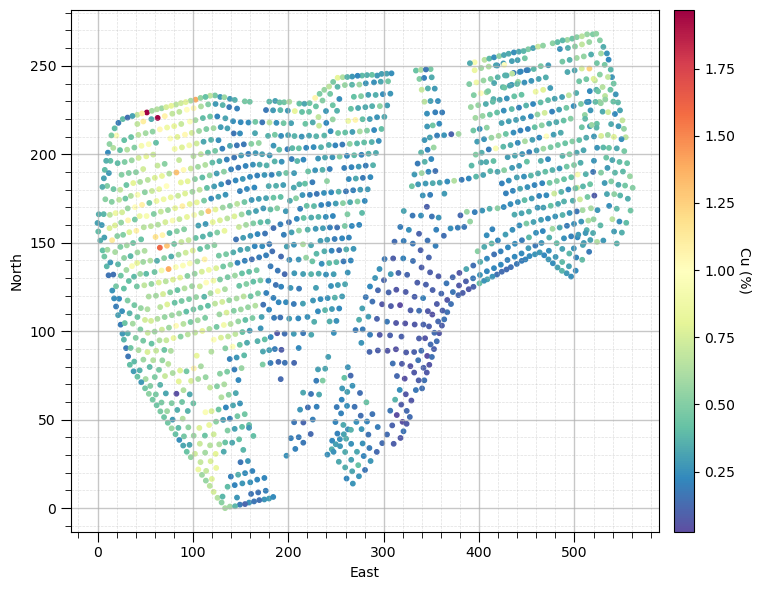

In [13]:
# ──────────────────────────────
# Create plot
# ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot
sc = ax.scatter(df_cu['EAST'], df_cu['NORTH'], s=10, c=df_cu['Cu'], cmap='Spectral_r')

# Labels
ax.set_xlabel('East')
ax.set_ylabel('North')

# Add grid
add_grid()

# Colorbar – tight with no excess padding
cbar = fig.colorbar(sc, ax=ax, shrink=1.0, aspect=25, pad=0.02)
cbar.set_label('Cu (%)', rotation=270, labelpad=12)
cbar.ax.tick_params(labelsize=10)

# ──────────────────────────────
# Save and show
# ──────────────────────────────
output_file = os.path.join(image_path, 'Cu_blast_hole_map.png')
plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()

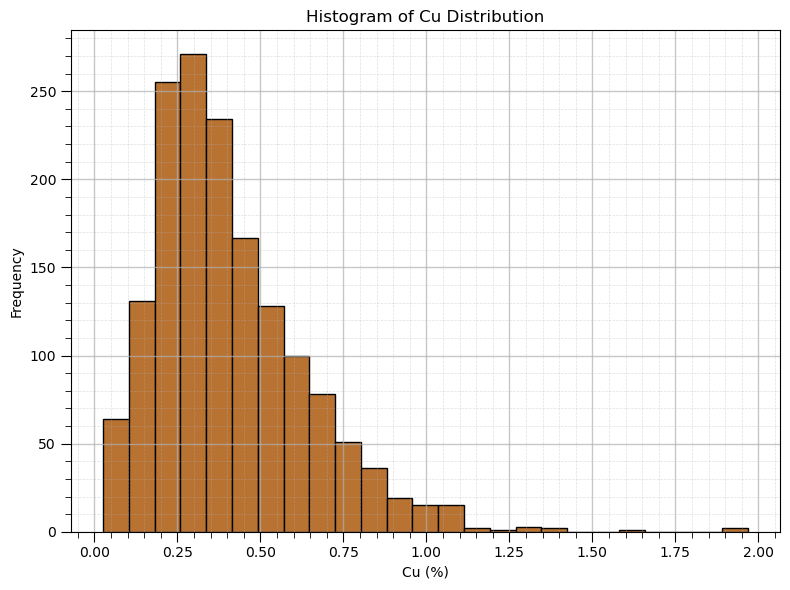

In [14]:
# ──────────────────────────────
# Custom grid function
# ──────────────────────────────
def add_grid(ax):
    ax.grid(True, which='major', linewidth=1.0, alpha=0.7)
    ax.grid(True, which='minor', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

# ──────────────────────────────
# Create histogram
# ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(df_cu['Cu'], bins=25, color='#B87333', edgecolor='black')

# Axis labels and title
ax.set_xlabel('Cu (%)')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Cu Distribution')

# Apply grid
add_grid(ax)

# ──────────────────────────────
# Save and show
# ──────────────────────────────
output_file = os.path.join(image_path, 'Cu_Histogram.png')
plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()


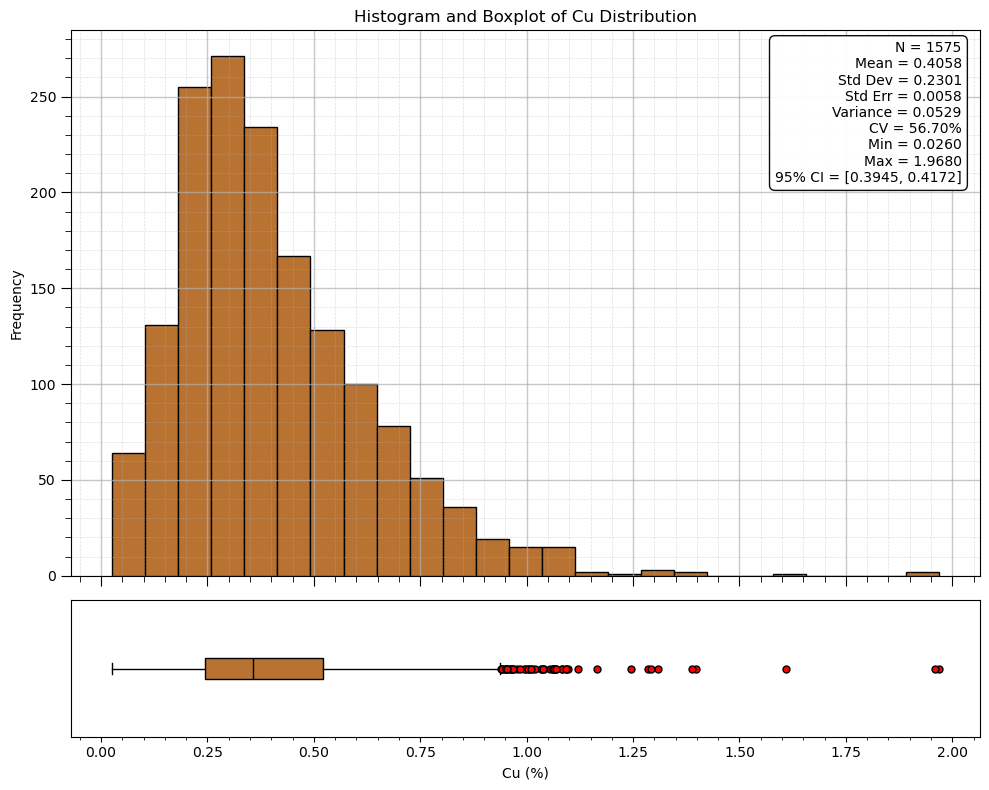

In [15]:

from scipy import stats
cu_data = df_cu['Cu'].dropna()

# ──────────────────────────────
# Compute stats
# ──────────────────────────────
n = cu_data.count()
mean = cu_data.mean()
std_dev = cu_data.std()
std_err = std_dev / np.sqrt(n)
var = cu_data.var()
cv = std_dev / mean * 100
min_ = cu_data.min()
max_ = cu_data.max()
ci95 = stats.norm.interval(0.95, loc=mean, scale=std_err)
lower_95, upper_95 = ci95

# ──────────────────────────────
# Format the stats text
# ──────────────────────────────
stats_text = (
    f"N = {n}\n"
    f"Mean = {mean:.4f}\n"
    f"Std Dev = {std_dev:.4f}\n"
    f"Std Err = {std_err:.4f}\n"
    f"Variance = {var:.4f}\n"
    f"CV = {cv:.2f}%\n"
    f"Min = {min_:.4f}\n"
    f"Max = {max_:.4f}\n"
    f"95% CI = [{lower_95:.4f}, {upper_95:.4f}]"
)

# ──────────────────────────────
# Custom grid helper
# ──────────────────────────────
def add_grid(ax):
    ax.grid(True, which='major', linewidth=1.0, alpha=0.7)
    ax.grid(True, which='minor', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

# ──────────────────────────────
# Create figure and axes
# ──────────────────────────────
fig, (ax_hist, ax_box) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 8),
    gridspec_kw={'height_ratios': [4, 1]},
    sharex=True
)

# Histogram
ax_hist.hist(cu_data, bins=25, color='#B87333', edgecolor='black')
ax_hist.set_ylabel("Frequency")
ax_hist.set_title("Histogram and Boxplot of Cu Distribution")
add_grid(ax_hist)

# Fancy stats box (anchored to top right)
props = dict(boxstyle="round,pad=0.4", facecolor='white', edgecolor='black', alpha=0.95)
ax_hist.text(
    0.98, 0.98, stats_text,
    transform=ax_hist.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=props
)

# Boxplot (horizontal, on top)
ax_box.boxplot(cu_data, vert=False, patch_artist=True,
               boxprops=dict(facecolor='#B87333', color='black'),
               medianprops=dict(color='black'),
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'),
               flierprops=dict(markerfacecolor='red', marker='o', markersize=5, linestyle='none'))

ax_box.set_xlabel("Cu (%)")
ax_box.set_yticks([])  # Hide y-axis ticks for boxplot
ax_box.set_ylabel("")  # Remove label
ax_box.grid(False)

# ──────────────────────────────
# Save and show
# ──────────────────────────────
plt.tight_layout()
output_file = os.path.join(image_path, 'Cu_Histogram_Boxplot.png')
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()


## Decluster data

<h1 style="color:darkgreen;">1. Source of Spatial Sampling Bias</h1>

<p>In general, all spatial data we work with should be assumed to contain bias. Data are not collected for statistical neutrality but to answer targeted questions or to optimise downstream performance. Common implicit acquisition motivations include:</p>

<ul style="color:darkgoldenrod;">
  <li><strong>How far does a plume or feature extend?</strong> — sampling concentrated near perceived boundaries or gradients.</li>
  <li><strong>Where is a structural feature (e.g., fault)?</strong> — acquisition guided by prior interpretations.</li>
  <li><strong>Where is the highest signal or grade?</strong> — preferentially sampling “the best” parts.</li>
  <li><strong>How can future output be supported?</strong> — site locations chosen with performance in mind.</li>
</ul>

<p>These decision-driven strategies produce an <strong>inaccessible population</strong> that is underrepresented or entirely missing from the raw sample set. Without correction, any summary statistics (means, variances, distributions) reflect acquisition intent rather than the target domain.</p>

<h2 style="color:#003366;">1.1 Random Sampling</h2>

<p><strong>Random sampling</strong> means every element of the underlying population has an equal and independent chance of being selected.</p>

<ul style="color:darkgoldenrod;">
  <li>Selections are independent.</li>
  <li>In practice, true random spatial sampling is rare in applied subsurface or environmental campaigns because it is uneconomic and misaligned with the primary questions driving data acquisition.</li>
  <li>Data are instead collected to answer specific questions or to support operational objectives, inducing systematic spatial bias.</li>
</ul>

<p><em>Is random sampling sufficient or available?</em></p>
<ul style="color:darkgoldenrod;">
  <li>No; it is usually infeasible in real campaigns.</li>
  <li>The spatial distribution of samples is driven by prior knowledge, interpretation, and value optimization.</li>
</ul>

<h2 style="color:#003366;">1.2 Regular Sampling</h2>

<p><strong>Regular sampling</strong> places samples on a fixed grid or at equal intervals.</p>

<ul style="color:darkgoldenrod;">
  <li>More structured than opportunistic sampling, but still not unbiased.</li>
  <li><strong>Warning:</strong> Regular spacing can alias with underlying periodic geological or environmental features, producing misleading apparent structures.</li>
</ul>

<h2 style="color:#003366;">1.3 What We Actually Have</h2>

<ul style="color:darkgoldenrod;">
  <li>Predominantly biased, opportunity-driven sampling designs.</li>
  <li>Raw spatial data therefore over- or under-represents regions for reasons unrelated to the true underlying distribution.</li>
  <li>Correcting (“debiasing”) is mandatory before inferring population-level statistics.</li>
</ul>

<p>Economic and operational realities usually preclude wholesale redesign of acquisition to achieve statistical ideals (e.g., proposing fully random sampling in an expensive drilling campaign). The practical path is to retain the existing data collection strategy and <strong>correct for its induced bias in analysis</strong>.</p>

<p><strong>Rule:</strong> Never use raw spatial data without assessing and correcting for sampling bias.</p>

<h1 style="color:darkgreen;">2. Cell-Based Declustering</h1>

<p>Cell-based declustering is a pragmatic debiasing technique. It overlays a regular spatial mesh (cells) on the sample locations and assigns weights so that samples in dense clusters contribute less and those in sparse regions contribute more. The aim is to recover summary statistics that approximate what would have been obtained under uniform representation.</p>

<h2 style="color:#003366;">2.1 Weight Calculation</h2>

<p>Let a sample at location $\mathbf{u}_j$ fall into cell $\ell$, and let:</p>

<ul style="color:darkgoldenrod;">
  <li>$n$ be the total number of samples.</li>
  <li>$n_{\ell}$ be the number of samples in cell $\ell$.</li>
  <li>$L_o$ be the number of occupied cells (cells containing at least one sample).</li>
</ul>

<p>The declustering weight is defined as:</p>

$$
w(\mathbf{u}_j) = \frac{1}{n_{\ell}} \cdot \frac{n}{L_o}
$$

<p>This ensures:</p>

<ul style="color:darkgoldenrod;">
  <li>The sum of all weights is $n$ (normalisation).</li>
  <li>Nominal weight equals 1.0 when sampling density is uniform.</li>
  <li>Dense regions ($n_{\ell}$ large) produce smaller per-sample weights; sparse regions gain relative influence.</li>
</ul>

<h2 style="color:#003366;">2.2 Robustness Enhancements</h2>

<ul style="color:darkgoldenrod;">
  <li><strong>Offset averaging:</strong> The arbitrary origin of the cell mesh influences how samples are binned. To remove sensitivity, compute weights across multiple random mesh origins and average them.</li>
  <li><strong>Cell size selection:</strong> The scale (cell size) controls smoothing versus resolution. The optimal size is chosen by inspecting how the declustered mean behaves: if the raw sample mean is suspected to be biased high, choose the cell size that <em>minimises</em> the declustered mean; if biased low, choose the size that <em>maximises</em> it.</li>
</ul>

<h1 style="color:darkgreen;">3. Parameterisation</h1>

<p>The declustering routine requires the following inputs:</p>

<ul style="color:darkgoldenrod;">
  <li><strong>df</strong> – DataFrame containing spatial samples.</li>
  <li><strong>xcol</strong> – Column name for the $x$ coordinate.</li>
  <li><strong>ycol</strong> – Column name for the $y$ coordinate.</li>
  <li><strong>vcol</strong> – Column name for the variable being summarised (e.g., grade, concentration).</li>
  <li><strong>iminmax</strong> – Indicator:  
    <ul>
      <li>1 = choose cell size that <em>minimises</em> the declustered mean.</li>
      <li>0 = choose cell size that <em>maximises</em> the declustered mean.</li>
    </ul>
  </li>
  <li><strong>noff</strong> – Number of random mesh offsets to average over (reduces origin dependence).</li>
  <li><strong>ncell</strong> – Number of candidate cell sizes between <strong>cmin</strong> and <strong>cmax</strong>.</li>
  <li><strong>cmin</strong> – Minimum cell size to evaluate.</li>
  <li><strong>cmax</strong> – Maximum cell size to evaluate.</li>
</ul>

<p><strong>Procedure:</strong></p>

<ol style="color:darkgoldenrod;">
  <li>Define a grid of cell sizes from <code>cmin</code> to <code>cmax</code> (e.g., 10 m to 2000 m) with <code>ncell</code> steps.</li>
  <li>For each cell size:</li>
    <ol type="a">
      <li>For each of the <code>noff</code> random offsets:  
        <ul>
          <li>Construct the cell mesh shifted by the offset.</li>
          <li>Assign each sample to its cell and compute $n_{\ell}$ for that configuration.</li>
          <li>Compute per-sample weights using $w(\mathbf{u}_j) = \frac{1}{n_{\ell}} \cdot \frac{n}{L_o}$.</li>
        </ul>
      </li>
      <li>Average the weights across the offsets to obtain stable weights for that cell size.</li>
      <li>Compute the declustered mean using those averaged weights (see Section 4).</li>
    </ol>
  <li>Select the optimal cell size according to the value of <code>iminmax</code>.</li>
</ol>

<h2 style="color:#003366;">3.1 Outputs</h2>

<ul style="color:darkgoldenrod;">
  <li><strong>wts</strong> – Final weight vector for each sample (summing to $n$).</li>
  <li><strong>cell_sizes</strong> – Array of evaluated cell sizes.</li>
  <li><strong>dmeans</strong> – Declusted means corresponding to each <code>cell_size</code>.</li>
</ul>

<p>These can be plotted as declustered mean versus cell size to visualise the diagnostic behaviour and selection point (e.g., the cell size where the declustered mean is minimised or maximised as per the chosen criterion).</p>

<h1 style="color:darkgreen;">4. Calculating Declustered / Weighted Statistics</h1>

<p>Given weights $w(\mathbf{u}_j)$, summary statistics are computed in their weighted forms to reflect the corrected population estimate.</p>

<h2 style="color:#003366;">4.1 Weighted Mean</h2>

$$
\mu = \frac{1}{\sum_{j=1}^{n} w(\mathbf{u}_j)} \sum_{j=1}^{n} w(\mathbf{u}_j) \, x(\mathbf{u}_j)
$$

<h2 style="color:#003366;">4.2 Weighted Variance</h2>

$$
\sigma^2 = \frac{1}{\sum_{j=1}^{n} w(\mathbf{u}_j)} \sum_{j=1}^{n} w(\mathbf{u}_j)\left(x(\mathbf{u}_j) - \mu\right)^2
$$

<h2 style="color:#003366;">4.3 Weighted Standard Deviation</h2>

$$
\sigma = \sqrt{ \frac{1}{\sum_{j=1}^{n} w(\mathbf{u}_j)} \sum_{j=1}^{n} w(\mathbf{u}_j)\left(x(\mathbf{u}_j) - \mu\right)^2 }
$$

<h2 style="color:#003366;">4.4 Practical Implementation</h2>

<p>A robust implementation uses <code>statsmodels</code>'s <code>DescrStatsW</code> class, which accepts the weight vector and provides weighted mean, variance, standard deviation, histograms, cumulative distribution functions, and confidence intervals without manual expansion. For one-off calculations it is also straightforward to implement the above sums directly.</p>

<h2 style="color:#003366;">4.5 Example Calculation</h2>

<p>Suppose we have 4 spatial samples with values $x = [10, 20, 30, 40]$ and, after declustering on a chosen cell size and offsets, weights:</p>

$$
w = [0.5, 1.5, 1.0, 1.0], \quad \text{so } \sum_j w_j = 4 \text{ (total sample count)}
$$

<p>Compute the weighted mean:</p>

$$
\mu = \frac{1}{4} \left(0.5 \cdot 10 + 1.5 \cdot 20 + 1.0 \cdot 30 + 1.0 \cdot 40\right)
= \frac{1}{4} (5 + 30 + 30 + 40) = \frac{105}{4} = 26.25
$$

<p>Weighted variance:</p>

$$
\sigma^2 = \frac{1}{4} \left[0.5(10 - 26.25)^2 + 1.5(20 - 26.25)^2 + 1.0(30 - 26.25)^2 + 1.0(40 - 26.25)^2\right]
$$

Compute each term:

- $(10 - 26.25)^2 = 264.0625$ → $0.5 \cdot 264.0625 = 132.03125$  
- $(20 - 26.25)^2 = 39.0625$ → $1.5 \cdot 39.0625 = 58.59375$  
- $(30 - 26.25)^2 = 14.0625$ → $1.0 \cdot 14.0625 = 14.0625$  
- $(40 - 26.25)^2 = 189.0625$ → $1.0 \cdot 189.0625 = 189.0625$  

Sum: $132.03125 + 58.59375 + 14.0625 + 189.0625 = 393.75$  

$$
\sigma^2 = \frac{393.75}{4} = 98.4375, \quad \sigma = \sqrt{98.4375} \approx 9.92
$$

<p>Thus the declustered (weighted) summary is: mean ≈ 26.25, standard deviation ≈ 9.92, which may differ appreciably from unweighted statistics if the original sample spacing was uneven.</p>

<h1 style="color:darkgreen;">Summary</h1>

<ul style="color:darkgoldenrod;">
  <li>All spatial sampling carries bias due to acquisition intent. Raw data must be corrected before making inferences about the target domain.</li>
  <li>Cell-based declustering reweights samples based on local sampling density, normalised to preserve total influence.</li>
  <li>Robustness is achieved with multiple mesh offsets and systematic cell size selection (minimising or maximising the declustered mean depending on suspected bias direction).</li>
  <li>Weighted statistics (mean, variance, etc.) computed with the declustering weights recover corrected descriptors that reflect the intended population more faithfully.</li>
</ul>


<h2 style="color:#003366;">Example: Cell-Based Declustering Calculation</h2>

<p>We illustrate with a minimal synthetic example. Suppose we have 6 samples located in 2D and we overlay a regular cell mesh with a chosen cell size. After one particular mesh origin (offset), the samples fall into occupied cells as follows:</p>

<ul style="color:darkgoldenrod;">
  <li>Cell A: 3 samples</li>
  <li>Cell B: 2 samples</li>
  <li>Cell C: 1 sample</li>
</ul>

<p>Thus:</p>

<ul style="color:darkgoldenrod;">
  <li>Total samples: $n = 6$</li>
  <li>Number of occupied cells: $L_o = 3$</li>
  <li>Counts per cell: $n_A = 3$, $n_B = 2$, $n_C = 1$</li>
</ul>

<p>Using the formula</p>

$$
w(\mathbf{u}_j) = \frac{1}{n_\ell} \cdot \frac{n}{L_o}
$$

<p>the nominal normalisation factor is $\frac{n}{L_o} = \frac{6}{3} = 2$. Therefore:</p>

<ul style="color:darkgoldenrod;">
  <li>Each sample in Cell A: $w = \frac{1}{3} \cdot 2 = \frac{2}{3} \approx 0.6667$</li>
  <li>Each sample in Cell B: $w = \frac{1}{2} \cdot 2 = 1.0$</li>
  <li>Each sample in Cell C: $w = \frac{1}{1} \cdot 2 = 2.0$</li>
</ul>

<p>If we list the six sample weights (e.g., three from A, two from B, one from C):</p>

$$
w = [0.6667, 0.6667, 0.6667,\; 1.0, 1.0,\; 2.0]
$$

<p>Check normalisation:</p>

$$
\sum_j w_j = 3 \times 0.6667 + 2 \times 1.0 + 1 \times 2.0 = 2.0 + 2.0 + 2.0 = 6 = n
$$

<p>This matches expectation.</p>

<h2 style="color:#003366;">Offset Averaging</h2>

<p>Suppose we repeat the above with a second random mesh origin and obtain a different set of cell occupancies yielding (after the same procedure) weights for the same six samples:</p>

$$
w' = [1.0, 1.0, 0.5,\; 1.5, 0.5,\; 1.5]
$$

<p>To reduce dependence on the arbitrary origin, average the two weight vectors elementwise:</p>

$$
\bar{w} = \frac{1}{2}(w + w') = \frac{1}{2} \bigl([0.6667+1.0,\; 0.6667+1.0,\; 0.6667+0.5,\; 1.0+1.5,\; 1.0+0.5,\; 2.0+1.5]\bigr)
$$

$$
\bar{w} = \frac{1}{2}([1.6667,\;1.6667,\;1.1667,\;2.5,\;1.5,\;3.5]) = [0.83335,\;0.83335,\;0.58335,\;1.25,\;0.75,\;1.75]
$$

<p>Sum to confirm:</p>

$$
\sum_j \bar{w}_j = 0.83335 + 0.83335 + 0.58335 + 1.25 + 0.75 + 1.75 \approx 6
$$

<p>These averaged weights are then used to compute the declustered mean or other statistics for that cell size. If multiple cell sizes are evaluated, the declustered mean is computed for each, and the optimal size is selected via the <code>iminmax</code> criterion.</p>

<h2 style="color:#003366;">Putting It Together: Declustered Mean for One Cell Size</h2>

<p>Given values $x(\mathbf{u}_j)$ associated with the six samples, the declustered (weighted) mean for this cell size is:</p>

$$
\mu_{\text{decl}} = \frac{1}{\sum_j \bar{w}_j} \sum_{j=1}^6 \bar{w}_j \, x(\mathbf{u}_j)
$$

<p>The same procedure (with averaging over offsets) is repeated across candidate cell sizes; the chosen size is the one that, depending on the suspected bias direction, minimises or maximises $\mu_{\text{decl}}$.</p>


There are 1575 data with:
   mean of      0.405832380952381 
   min and max  0.026 and 1.968
   standard dev 0.23001832880532494 


100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [01:42<00:00,  1.95it/s]


Naive mean = 0.406
Declustered mean = 0.38
Plot saved to images\declustered_mean_vs_cell_size.png


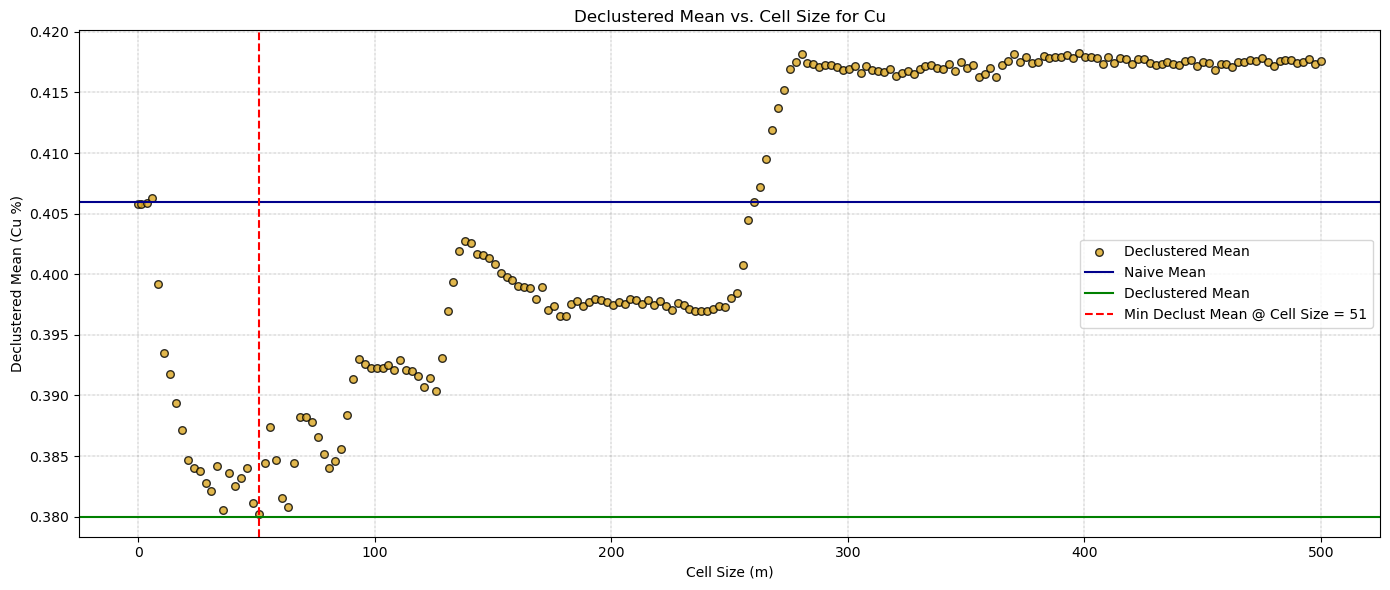

In [16]:

from statsmodels.stats.weightstats import DescrStatsW

# ──────────────────────────────
# Assumes df_cu already exists and has 'EAST', 'NORTH', 'Cu'
df_cu["declust_weight"], cell_size, declust_means = geostat.declus(
    df_cu, 'EAST', 'NORTH', 'Cu',
    iminmax=1, noff=100, ncell=200, cmin=1, cmax=500
)

# ──────────────────────────────
# Calculate naive and declustered means
# ──────────────────────────────
weighted_data = DescrStatsW(df_cu["Cu"].values, weights=df_cu["declust_weight"].values, ddof=0)
dmean = round(weighted_data.mean, 3)
naive_mean = round(np.mean(df_cu["Cu"].values), 3)

print("Naive mean =", naive_mean)
print("Declustered mean =", dmean)

# ──────────────────────────────
# Identify best declustered cell size (min of declust_means)
# ──────────────────────────────
min_dmean_idx = np.argmin(declust_means)
best_cell_size = cell_size[min_dmean_idx]
min_declust_val = declust_means[min_dmean_idx]

# ──────────────────────────────
# Create the plot
# ──────────────────────────────
plt.figure(figsize=(14, 6))
plt.scatter(cell_size, declust_means, s=30, alpha=0.8,
            edgecolors="black", facecolors='goldenrod', label='Declustered Mean')

# Horizontal lines
plt.axhline(y=naive_mean, color='darkblue', linestyle='-', label='Naive Mean')
plt.axhline(y=dmean, color='green', linestyle='-', label='Declustered Mean')

# Vertical line at minimum declustered mean
plt.axvline(x=best_cell_size, color='red', linestyle='--',
            label=f'Min Declust Mean @ Cell Size = {best_cell_size:.0f}')

# Labels, title, grid, legend
plt.xlabel('Cell Size (m)')
plt.ylabel('Declustered Mean (Cu %)')
plt.title('Declustered Mean vs. Cell Size for Cu')
plt.grid(color='grey', linestyle='-.', linewidth=0.3, which='both')
plt.legend()

# ──────────────────────────────
# Save the figure
# ──────────────────────────────
save_path = os.path.join(image_path, 'declustered_mean_vs_cell_size.png')
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to {save_path}")

# Show the plot
plt.show()


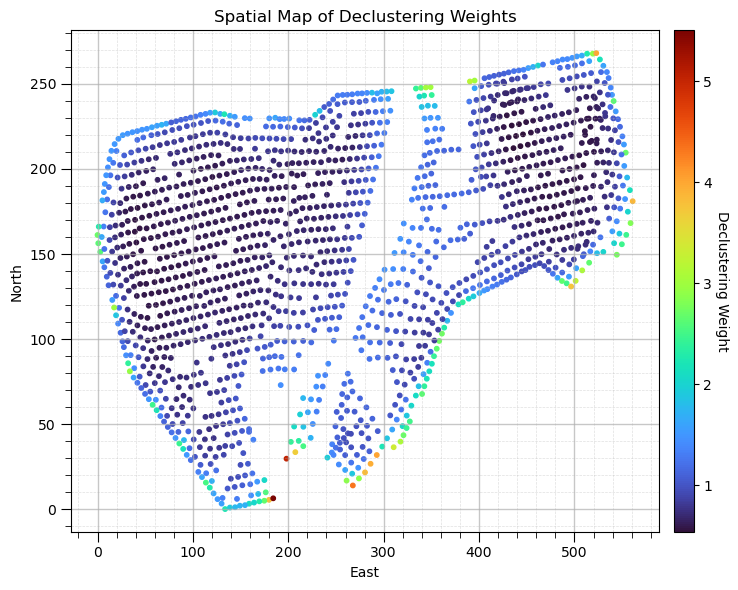

In [17]:
# ──────────────────────────────
# Custom grid helper
# ──────────────────────────────
def add_grid(ax):
    ax.grid(True, which='major', linewidth=1.0, alpha=0.7)
    ax.grid(True, which='minor', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

# ──────────────────────────────
# Create plot
# ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot of declustering weights
sc = ax.scatter(
    df_cu['EAST'], df_cu['NORTH'],
    s=10,
    c=df_cu['declust_weight'],
    cmap='turbo'  # Or any perceptual colormap like 'plasma', 'inferno'
)

# Labels
ax.set_xlabel('East')
ax.set_ylabel('North')
ax.set_title('Spatial Map of Declustering Weights')

# Add grid
add_grid(ax)

# Add colourbar
cbar = fig.colorbar(sc, ax=ax, shrink=1.0, aspect=25, pad=0.02)
cbar.set_label('Declustering Weight', rotation=270, labelpad=12)
cbar.ax.tick_params(labelsize=10)

# ──────────────────────────────
# Save and show
# ──────────────────────────────
output_file = os.path.join(image_path, 'Declust_Weight_Map.png')
plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()


<h1 style="color:darkgreen;">Data Distribution Transformations</h1>

<p><strong>Why do we perform distribution transformations in geostatistical methods and workflows?</strong></p>

<ul style="color:darkgoldenrod;">
  <li><strong>Variable has unexpected shape:</strong> raw sample distributions may be skewed, multi-modal, or otherwise incompatible with modelling assumptions.</li>
  <li><strong>Too few data:</strong> small sample sizes make empirical statistics noisy; transformations can stabilise behaviour when combined with reference information.</li>
  <li><strong>Specific distributional assumptions:</strong> many geostatistical algorithms—kriging variants, search neighbourhood definitions, simulation back-transformations—assume Gaussianity (or approximate it) for optimal performance.</li>
  <li><strong>Outlier mitigation:</strong> transforms such as normal scores compress extreme tails and prevent a few values from dominating spatial continuity estimation.</li>
</ul>

<h1 style="color:darkgreen;">Normal Score Transform / Gaussian Anamorphosis</h1>

<p>Affine corrections (shifting mean to 0 and scaling variance to 1) do not change the shape of a distribution and therefore do not produce Gaussian data when the original is non-Gaussian. For workflows requiring approximately Gaussian behaviour, a <strong>normal score transform</strong> (Gaussian anamorphosis) remaps the original variable through its cumulative distribution function (CDF) into standard normal space, and provides a consistent inverse to return to original units.</p>

<p>Let $X$ be the original variable with empirical CDF $F_X$, and let $G_Y$ be the target Gaussian CDF (standard normal). Then the transforms are:</p>

<ul style="color:darkgoldenrod;">
  <li><strong>Forward transform:</strong>  
    $$Y = G_Y^{-1}(F_X(X))$$  
    i.e., map the probability $F_X(X)$ into Gaussian quantiles.</li>
  <li><strong>Reverse transform:</strong>  
    $$X = F_X^{-1}(G_Y(Y))$$  
    i.e., map a Gaussian value back to the original distribution via its quantiles.</li>
</ul>

<p>The inputs are primarily:</p>

<ul style="color:darkgoldenrod;">
  <li><strong>df</strong> – DataFrame containing the samples.</li>
  <li><strong>vcol</strong> – Column name of the variable to transform.</li>
  <li><strong>wcol</strong> – Column of weights (optional; defaults to uniform if omitted).</li>
  <li>Additional optional inputs specify a <strong>reference distribution</strong>. A reference distribution is used when the empirical sample size is too small or too noisy to reliably estimate $F_X$; analogue or prior data inform a more stable target CDF, which is then blended or substituted for the sparse empirical estimate.</li>
</ul>

<p><strong>When to use a reference distribution:</strong>  
If your sample count is limited (e.g., $n < 30$) or gaps leave parts of the support poorly represented, you can borrow an analogous distribution from another dataset (geologically, spatially, or historically similar) to regularise $F_X$. This can be done by:</p>

<ul style="color:darkgoldenrod;">
  <li>Replacing $F_X$ with the reference CDF outright when empirical is too unreliable.</li>
  <li>Blending: $F_{\text{blend}} = \alpha F_X + (1-\alpha) F_{\text{ref}}$ with weight $\alpha$ reflecting empirical confidence.</li>
</ul>

<h2 style="color:#003366;">Weighted Empirical CDF</h2>

<p>When weights $w_j = w(\mathbf{u}_j)$ are available (e.g., from declustering), the empirical CDF at a sample value $x_i$ is computed using plotting positions that account for weight:</p>

$$
F_X(x_i)
=
\frac{
\sum_{j: x_j < x_i} w_j + 0.5\,w_i
}
{W_{\text{tot}}}
\quad\text{where } W_{\text{tot}} = \sum_{j=1}^{n} w_j
$$

<p>This is a weighted analogue of the mid-point plotting position, ensuring continuity and that $F_X$ stays strictly between 0 and 1 for finite samples.</p>

<h2 style="color:#003366;">Outputs</h2>

<ul style="color:darkgoldenrod;">
  <li><strong>Transformed data:</strong> $Y$ values in standard normal space.</li>
  <li><strong>Transformation table:</strong> Discretised mapping between original $x$ values and their corresponding $y$ (Gaussian) quantiles (and vice versa) for interpolation during forward/reverse transforms.</li>
</ul>

<h2 style="color:#003366;">Example Calculations</h2>

<p>We demonstrate a fully worked example with weights.</p>

<h3 style="color:#003366;">Step 1: Data and weights</h3>

<p>Suppose we have 4 samples:</p>

- $x = [2,\;5,\;7,\;10]$  
- weights $w = [1,\;2,\;1,\;1]$ (total weight $W_{\text{tot}} = 5$)

<h3 style="color:#003366;">Step 2: Compute weighted empirical CDF (midpoint plotting positions)</h3>

<p>Order is already ascending. For each $x_i$:</p>

<ul style="color:darkgoldenrod;">
  <li>$F_X(2) = \dfrac{0 + 0.5 \cdot 1}{5} = \dfrac{0.5}{5} = 0.1$</li>
  <li>$F_X(5) = \dfrac{1 + 0.5 \cdot 2}{5} = \dfrac{1 + 1}{5} = \dfrac{2}{5} = 0.4$</li>
  <li>$F_X(7) = \dfrac{1 + 2 + 0.5 \cdot 1}{5} = \dfrac{3 + 0.5}{5} = \dfrac{3.5}{5} = 0.7$</li>
  <li>$F_X(10) = \dfrac{1 + 2 + 1 + 0.5 \cdot 1}{5} = \dfrac{4 + 0.5}{5} = \dfrac{4.5}{5} = 0.9$</li>
</ul>

<h3 style="color:#003366;">Step 3: Forward transform to Gaussian space</h3>

<p>Let $G_Y$ be the standard normal CDF and $\Phi^{-1}$ its inverse. Then:</p>

$$
Y_i = \Phi^{-1}(F_X(x_i))
$$

<p>Using standard normal quantiles (approximate):</p>

<ul style="color:darkgoldenrod;">
  <li>$Y(2) = \Phi^{-1}(0.1) \approx -1.2816$</li>
  <li>$Y(5) = \Phi^{-1}(0.4) \approx -0.2533$</li>
  <li>$Y(7) = \Phi^{-1}(0.7) \approx 0.5244$</li>
  <li>$Y(10) = \Phi^{-1}(0.9) \approx 1.2816$</li>
</ul>

<p>This yields transformed values $Y \approx [-1.28,\; -0.25,\; 0.52,\; 1.28]$, which now live in Gaussian space with approximately standard normal behaviour.</p>

<h3 style="color:#003366;">Step 4: Reverse transform example</h3>

<p>Suppose after processing in Gaussian space you obtain $Y=0$ (the median). Then:</p>

$$
F = \Phi(0) = 0.5
$$

<p>To get back to $X$, find $x$ such that the empirical CDF is 0.5. In our discrete weighted CDF, $F_X(5)=0.4$ and $F_X(7)=0.7$, so 0.5 lies between them. Interpolate linearly:</p>

$$
x = 5 + \frac{0.5 - 0.4}{0.7 - 0.4} \cdot (7 - 5)
= 5 + \frac{0.1}{0.3} \cdot 2
= 5 + \frac{2}{3} \approx 5.67
$$

<p>So $Y=0$ maps back to approximately $X=5.67$ under the empirical (weighted) transform.</p>

<h2 style="color:#003366;">Notes</h2>

<ul style="color:darkgoldenrod;">
  <li>Exact quantile interpolation method can be refined (e.g., monotonic spline, piecewise linear, or kernel smoothing) depending on desired smoothness.</li>
  <li>If weights are all equal, the procedure reduces to the unweighted empirical quantile transform.</li>
  <li>With very sparse data, the empirical CDF can be jagged; using a reference distribution or blending with one improves stability—particularly in the tails.</li>
  <li>The forward/backward transforms must be consistent; store the transformation table (pairs of $(x, y)$) for reuse during simulation or back-transformation of predictions.</li>
</ul>


In [18]:
df_cu["nscore"], tv, tns = geostats.nscore(df_cu, "Cu", "declust_weight")
df_cu.head()

,EAST,NORTH,Cu,declust_weight,nscore
0,56.122424,105.841818,0.750,0.625712,1.505209
1,74.176970,81.483939,0.664,0.695047,1.245968
2,140.032424,191.491515,0.202,0.621814,-0.847108
3,158.912121,133.599697,0.408,0.648315,0.351693
4,50.455455,211.942121,0.602,0.892424,1.066040


## Plot NSCORE

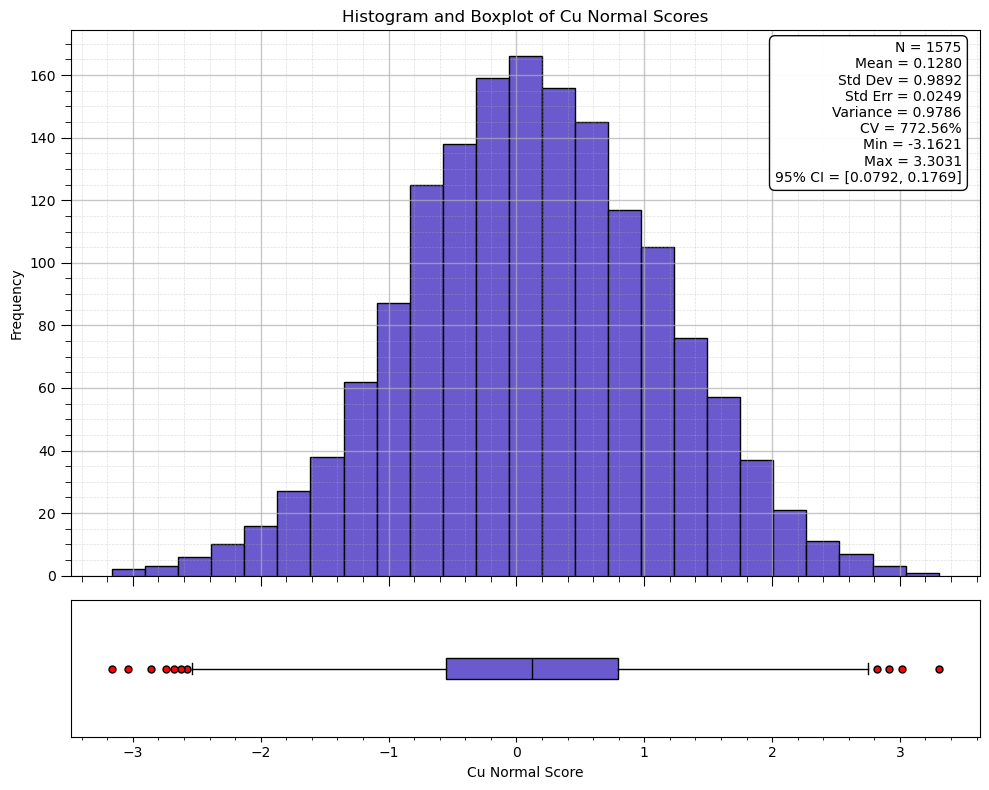

In [19]:

# ──────────────────────────────
# Extract non-NaN nscore values
# ──────────────────────────────
nscore_data = df_cu['nscore'].dropna()

# ──────────────────────────────
# Compute statistics
# ──────────────────────────────
n = nscore_data.count()
mean = nscore_data.mean()
std_dev = nscore_data.std()
std_err = std_dev / np.sqrt(n)
var = nscore_data.var()
cv = std_dev / mean * 100 if mean != 0 else np.nan
min_ = nscore_data.min()
max_ = nscore_data.max()
ci95 = stats.norm.interval(0.95, loc=mean, scale=std_err)
lower_95, upper_95 = ci95

# ──────────────────────────────
# Format the stats box text
# ──────────────────────────────
stats_text = (
    f"N = {n}\n"
    f"Mean = {mean:.4f}\n"
    f"Std Dev = {std_dev:.4f}\n"
    f"Std Err = {std_err:.4f}\n"
    f"Variance = {var:.4f}\n"
    f"CV = {cv:.2f}%\n"
    f"Min = {min_:.4f}\n"
    f"Max = {max_:.4f}\n"
    f"95% CI = [{lower_95:.4f}, {upper_95:.4f}]"
)

# ──────────────────────────────
# Custom grid helper
# ──────────────────────────────
def add_grid(ax):
    ax.grid(True, which='major', linewidth=1.0, alpha=0.7)
    ax.grid(True, which='minor', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

# ──────────────────────────────
# Create figure with histogram + boxplot
# ──────────────────────────────
fig, (ax_hist, ax_box) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 8),
    gridspec_kw={'height_ratios': [4, 1]},
    sharex=True
)

# Histogram of nscore
ax_hist.hist(nscore_data, bins=25, color='slateblue', edgecolor='black')
ax_hist.set_ylabel("Frequency")
ax_hist.set_title("Histogram and Boxplot of Cu Normal Scores")
add_grid(ax_hist)

# Stats box in upper right
props = dict(boxstyle="round,pad=0.4", facecolor='white', edgecolor='black', alpha=0.95)
ax_hist.text(
    0.98, 0.98, stats_text,
    transform=ax_hist.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=props
)

# Boxplot (horizontal)
ax_box.boxplot(nscore_data, vert=False, patch_artist=True,
               boxprops=dict(facecolor='slateblue', color='black'),
               medianprops=dict(color='black'),
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'),
               flierprops=dict(markerfacecolor='red', marker='o', markersize=5, linestyle='none'))

ax_box.set_xlabel("Cu Normal Score")
ax_box.set_yticks([])
ax_box.set_ylabel("")
ax_box.grid(False)

# ──────────────────────────────
# Save and show
# ──────────────────────────────
output_file = os.path.join(image_path, 'Cu_NScore_Histogram_Boxplot.png')
plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()


This is a q-q plot that maps the transform from our original distribution to the Gaussian distribution. Notice how the declustering weights have shifted the lower quantiles to above an imaginary line through the points as they received more declustering weight.

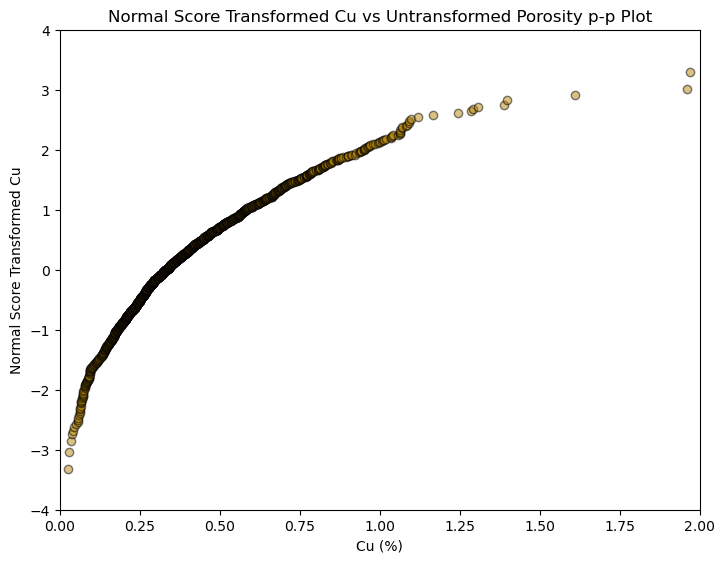

In [20]:
plt.subplot(111)
plt.scatter(tv, tns, c = "darkgoldenrod",edgecolor='black',marker='o', alpha = 0.5)
plt.xlabel('Cu (%)')
plt.ylabel('Normal Score Transformed Cu')
plt.title('Normal Score Transformed Cu vs Untransformed Porosity p-p Plot')
plt.ylim(-4,4); plt.xlim(0,2); 
#add_grid()

plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.2, hspace=0.2)
plt.show()

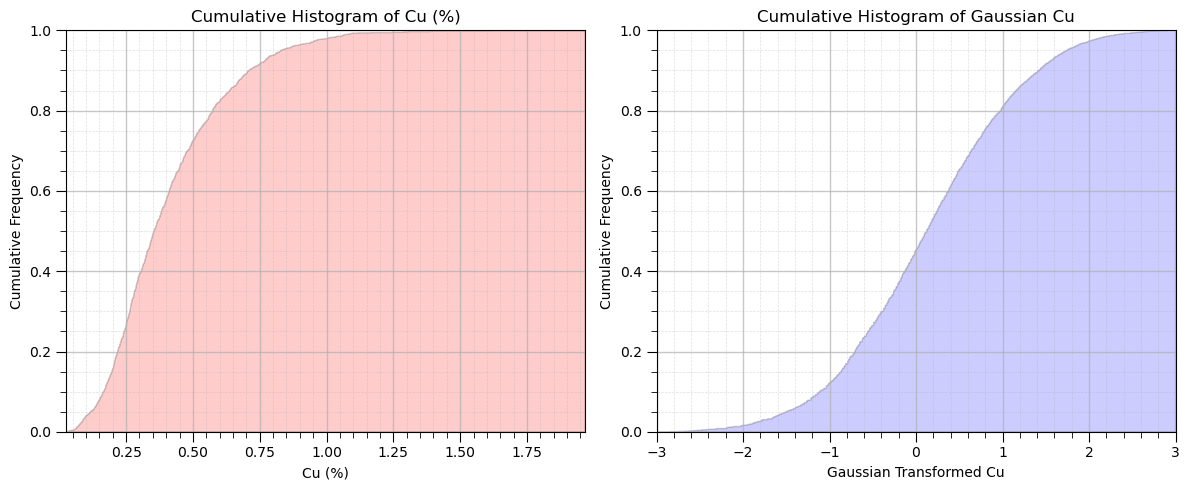

In [21]:
# ──────────────────────────────
# Custom grid function
# ──────────────────────────────
def add_grid(ax):
    ax.grid(True, which='major', linewidth=1.0, alpha=0.7)
    ax.grid(True, which='minor', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())


# ──────────────────────────────
# Data setup
# ──────────────────────────────
df = df_cu.copy()
feature = "Cu"
feature_units = "%"
vmin, vmax = df[feature].min(), df[feature].max()

# ──────────────────────────────
# Create figure and subplots
# ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# ───── Left: CDF of raw Cu ─────
ax1.hist(
    df[feature],
    bins=np.linspace(vmin, vmax, 1000),
    facecolor='red',
    edgecolor='black',
    histtype="stepfilled",
    alpha=0.2,
    density=True,
    cumulative=True
)
ax1.set_xlim([vmin, vmax])
ax1.set_ylim([0, 1.0])
ax1.set_xlabel(f"{feature} ({feature_units})")
ax1.set_ylabel("Cumulative Frequency")
ax1.set_title(f"Cumulative Histogram of {feature} (%)")
add_grid(ax1)

# ───── Right: CDF of nscore ─────
ax2.hist(
    df["nscore"],
    bins=np.linspace(-3.0, 3.0, 1000),
    facecolor='blue',
    edgecolor='black',
    histtype="stepfilled",
    alpha=0.2,
    density=True,
    cumulative=True
)
ax2.set_xlim([-3.0, 3.0])
ax2.set_ylim([0, 1.0])
ax2.set_xlabel(f"Gaussian Transformed {feature}")
ax2.set_ylabel("Cumulative Frequency")
ax2.set_title(f"Cumulative Histogram of Gaussian {feature}")
add_grid(ax2)

# ──────────────────────────────
# Final layout and save
# ──────────────────────────────
plt.tight_layout()
output_file = os.path.join(image_path, 'Cu_CuNScore_CDF.png')
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()


<h1 style="color:darkgreen;">1. Variogram Observations</h1>
<p>Spatial variability can be quantified using the variogram, which measures how differences between sample values increase with separation distance. Below are detailed observations applicable in one‑, two‑, and three‑dimensional settings.</p>

<h2 style="color:#003366;">1.1 Observation 1: Increasing Variability with Distance</h2>
<p>Across geological and environmental datasets, it is universally observed that semivariance increases with lag distance. This phenomenon arises because points closer together tend to share more similar environmental or geological characteristics than those farther apart.</p>

<ul style="color:darkgoldenrod;">
  <li><strong>1D example:</strong> In core logging, measurements of porosity taken at successive depths (e.g. 1 m apart) will typically vary less than measurements taken 10 m apart. The semivariance at lag <em>h=1 m</em> is, therefore, smaller than at <em>h=10 m</em>.</li>
  <li><strong>2D example:</strong> On a mineral concentration map, two locations separated by 50 m often yield more similar assay values than two locations separated by 500 m.</li>
  <li><strong>3D example:</strong> For orebody modelling, volumetric grid blocks that are closer in three‑dimensional space exhibit stronger correlation, while blocks separated by greater radial distances show higher semivariance.</li>
</ul>

<p><strong>Exceptions and artefacts:</strong> A periodic geological feature can produce a “hole effect,” wherein semivariance decreases over specific lag intervals. At very large lag distances, often beyond half the maximum dimension of the dataset, the variogram can display negative slopes. This is an artifact of insufficient sample pairs at those distances rather than true geological continuity.</p>

<h2 style="color:#003366;">1.2 Observation 2: Computation Across All Sample Pairs</h2>
<p>The experimental variogram is estimated by scanning all sample pairs separated by a lag vector <em>\(\mathbf{h}\)</em> and computing half the squared difference of their values. In 1D, the lag vector reduces to a scalar distance; in 2D and 3D, it represents a directional offset in the horizontal plane or volumetric space.</p>


\begin{equation}
\gamma(\mathbf{h}) = \frac{1}{2\,N(\mathbf{h})}
\sum_{\alpha=1}^{N(\mathbf{h})}
\bigl[z(\mathbf{u}_\alpha) - z(\mathbf{u}_\alpha + \mathbf{h})\bigr]^2
\tag{1}
\end{equation}


<p><strong>Explanation:</strong> Equation (1) defines the semivariogram. Here, <em>z(\mathbf{u}_\alpha)</em> is the value at the tail of the vector, and <em>z(\mathbf{u}_\alpha + \mathbf{h})</em> is the value at the head. The summation averages squared differences across all <em>N(\mathbf{h})</em> pairs. This approach ensures the variogram captures spatial continuity faithfully, whether along a single direction (1D), within a plane (2D), or throughout a volume (3D).</p>

<h2 style="color:#003366;">1.3 Observation 3 &ndash; Sill, Covariance, and Correlogram</h2>
<p>After computing semivariance for increasing lags, the variogram typically levels off at the <strong>sill</strong>, denoted <em>σ<sub>x</sub><sup>2</sup></em>, representing the variable’s intrinsic variance under stationarity.</p>


\begin{equation}
C_x(\mathbf{h}) = \sigma_x^2 - \gamma(\mathbf{h})
\tag{2}
\end{equation}


<p><strong>Explanation:</strong> Equation (2) shows how covariance is the mirror image of the variogram. When data are standardized so that <em>σ<sub>x</sub><sup>2</sup> = 1</em>, the covariance function becomes the <strong>correlogram</strong>:</p>


\begin{equation}
\rho_x(\mathbf{h}) = 1 - \gamma(\mathbf{h})
\tag{3}
\end{equation}


<p>A correlogram value of 1 indicates perfect correlation at that lag, whereas a value of 0 denotes no correlation. In 3D modelling, covariance functions help define kriging weights that honour both horizontal and vertical continuity structures.</p>

<h2 style="color:#003366;">1.4 Observation 4 &ndash; Range of Influence</h2>
<p>The <strong>range</strong> is the critical distance at which <em>γ(\mathbf{h})</em> reaches the sill and beyond which additional separation does not increase semivariance. In 1D, it is a linear distance; in 2D, it is the radial distance within the map plane; in 3D, it describes the radius of an influence sphere.</p>

<h2 style="color:#003366;">1.5 Observation 5 &ndash; Nugget Effect and Microscale Variability</h2>
<p>A nonzero semivariance at vanishingly small lags (approaching zero) is called the <strong>nugget effect</strong>, reflecting microscale variability or measurement noise that cannot be resolved by the sampling interval. The relative nugget effect (nugget divided by sill) quantifies the proportion of variance attributable to this unresolved component. In high‑resolution 3D models, distinguishing nugget from legitimate fine‑scale variability is crucial to prevent overfitting noise.</p>



<h1 style="color:darkgreen;">2. Defining Variogram Calculation Parameters</h1>
<p>To compute an experimental variogram in 1D, 2D, or 3D, a search template must be established:</p>

<ul style="color:darkgoldenrod;">
  <li><strong>Lag vector components:</strong>
    <ul style="color:darkgoldenrod;">
      <li><strong>Horizontal azimuth</strong> (θ) degrees clockwise from North, e.g. 045° in map view. Visualise a 360° pie: 45° is one‑eighth of the pie.</li>
      <li><strong>Vertical plunge/inclination</strong> (φ) degrees below horizontal for 3D variograms.</li>
    </ul>
  </li>
  <li><strong>Lag distance</strong> (r): Minimum separation, typically at least the smallest sample spacing.</li>
  <li><strong>Lag tolerance</strong>: Half‑width of radial search shell, e.g. ±0.5 r, to capture pairs near the target separation.</li>
  <li><strong>Azimuth/plunge tolerances</strong>: Angular windows controlling directional specificity, e.g. ±22.5° around target in 2D or ±10° dip in 3D.</li>
  <li><strong>Bandwidth limit</strong>: Maximum perpendicular distance to the lag vector for including pairs, particularly important in anisotropic calculations.</li>
</ul>

<p><strong>Explanation:</strong> Selecting tight tolerances increases directional accuracy but may reduce sample pairs, leading to noisy variograms. Conversely, wide tolerances smooth noise at the expense of directional precision.</p>



<h1 style="color:darkgreen;">3. Isotropic Versus Anisotropic Experimental Variograms</h1>
<p>An <strong>isotropic variogram</strong> pools pairs from all directions (azimuth tolerance = 90°), yielding an average measure of spatial continuity. This approach ignores preferential directions but is useful for a first‑order overview.</p>

<p><strong>Anisotropic variograms</strong> isolate sample pairs within narrow angular tolerances around principal directions:</p>

<ul style="color:darkgoldenrod;">
  <li><strong>2D:</strong> Major and minor horizontal azimuths reveal directional correlation lengths.</li>
  <li><strong>3D:</strong> Strike, dip, and plunge directions elucidate volumetric continuity along fractures or layering.</li>
</ul>

<p>Directional variograms are essential for modelling features such as elongated ore bodies, fault‑controlled mineralisation, or sedimentary layering.</p>



<h1 style="color:darkgreen;">4. Formal Definition of the Semivariogram</h1>
<p>Across any dimension, the semivariogram formula remains:</p>


\begin{equation}
\gamma(\mathbf{h}) = \frac{1}{2\,N(\mathbf{h})} \
  \sum_{\alpha=1}^{N(\mathbf{h})}
  \bigl[z(\mathbf{u}_\alpha) - z(\mathbf{u}_\alpha + \mathbf{h})\bigr]^2
\tag{4}
\end{equation}


<p>This unbiased estimator quantifies the average squared difference for pairs separated by <em>h</em>, forming the basis for all variogram modelling in geostatistics.</p>



<h1 style="color:darkgreen;">5. Interpretation of Variogram Features</h1>

<h2 style="color:#003366;">5.1 Geometric Anisotropy</h2>
<p>When the shape of the variogram is consistent but the range differs by direction, geometric anisotropy is present. For example, horizontal correlation may extend hundreds of metres along bedding planes but only tens of metres vertically.</p>

<h2 style="color:#003366;">5.2 Variogram Cyclicity</h2>
<p>Periodic oscillations in the variogram indicate repeating spatial structures (e.g. depositional cycles) and must be distinguished from random noise by ensuring adequate sample density.</p>

<h2 style="color:#003366;">5.3 Zonal Anisotropy and Apparent Sill</h2>
<p>In some directions, the variogram may not reach the global sill within the maximum lag. The plateau it does reach—the apparent sill—allows partitioning of variance into within‑zone and between‑zone components.</p>

<h2 style="color:#003366;">5.4 Trends and Nonstationarity</h2>
<p>A continuous linear rise in the variogram beyond the sill signals a spatial trend or drift. Removing this trend by detrending the data restores stationarity, enabling accurate modelling of the residual variogram.</p>



<h1 style="color:darkgreen;">6. Rationale for Variogram Modelling</h1>
<p>Variogram modelling serves three primary purposes:</p>
<ul style="color:darkgoldenrod;">
  <li><strong>Completeness:</strong> Provide semivariance values for all lag vectors, not only those computed experimentally.</li>
  <li><strong>Integration of geological knowledge:</strong> Encode fault orientations, depositional directions, or anisotropic permeability pathways into the model.</li>
  <li><strong>Mathematical validity:</strong> Ensure the model is positive definite, a requirement for kriging and stochastic simulations that guarantees non‑negative variance for any linear combination of sample values.</li>
</ul>



<h1 style="color:darkgreen;">7. Nested Variogram Models for Complex Continuity</h1>
<p>Complex spatial continuity is represented by summing multiple nested variograms:</p>


\begin{equation}
\Gamma_x(\mathbf{h}) = \sum_{i=1}^{nst} \gamma_i(\mathbf{h})
\tag{5}
\end{equation}


<p>Each nested structure <em>γ<sub>i</sub></em> incorporates geometric anisotropy:</p>
<ul style="color:darkgoldenrod;">
  <li><strong>2D/3D azimuth</strong> <em>a<sub>z,i</sub></em></li>
  <li><strong>3D plunge</strong> <em>a<sub>p,i</sub></em></li>
  <li><strong>Major range</strong> <em>a<sub>maj,i</sub></em> and <strong>minor range</strong> <em>a<sub>min,i</sub></em></li>
</ul>

<p>Off‑axis distances are interpolated using the anisotropy ellipse:</p>


\begin{equation}
 h_i = \sqrt{\left(\frac{r_{maj}}{a_{maj,i}}\right)^2
       + \left(\frac{r_{maj}}{a_{min,i}}\right)^2}
\tag{6}
\end{equation}


<p>Nested models allow representation of multiple scales of variability, from nugget to short‑ and long‑range structures.</p>



<h1 style="color:darkgreen;">8. Positive Definiteness and Choices of Variogram Models</h1>
<p>Geostatisticians select positive‑definite variogram structures to ensure valid spatial predictions:</p>
<ul style="color:darkgoldenrod;">
  <li><strong>Nugget:</strong> Unresolved variability at infinitesimal lag.</li>
  <li><strong>Spherical:</strong> Linear rise to sill, then flat.</li>
  <li><strong>Exponential:</strong> Exponential rise towards sill.</li>
  <li><strong>Gaussian:</strong> Smooth, parabolic initial rise.</li>
</ul>
<p>Less common alternatives include:</p>
<ul style="color:darkgoldenrod;">
  <li><strong>Hole effect:</strong> Models cyclic continuity with oscillations around the sill.</li>
  <li><strong>Damped hole effect:</strong> Oscillations that attenuate with distance.</li>
  <li><strong>Power law:</strong> No sill; variance increases without bound, appropriate for fractal‑like processes.</li>
</ul>

<p>Each component must be positive definite in the intended dimensionality (1D line, 2D map, 3D volume) to ensure the resulting model supports unbiased kriging and realistic stochastic simulations.</p>



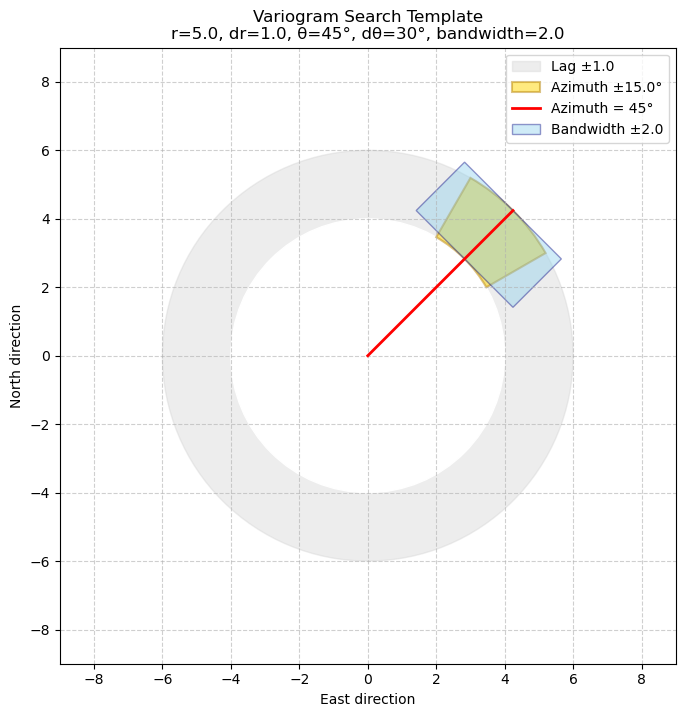

In [22]:

"""
Illustrate a 2D variogram search template:
  - Lag distance r
  - Lag tolerance dr (annulus)
  - Azimuth direction theta
  - Azimuth tolerance dtheta (wedge)
  - Bandwidth limit (perpendicular distance to the lag vector)
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle, Polygon

def plot_variogram_search_template(
    r=5.0,
    dr=1.0,
    theta=45.0,
    dtheta=30.0,
    bandwidth=2.0,
    show=True
):
    """
    Draw a 2D variogram search template.

    Parameters
    ----------
    r : float
        Central lag distance.
    dr : float
        Lag tolerance (half-width).
    theta : float
        Azimuth in degrees, measured clockwise from North (which is +Y here).
    dtheta : float
        Azimuth tolerance in degrees (total width).
    bandwidth : float
        Perpendicular tolerance (half-width) to the lag vector.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect("equal", "box")

    # Draw the annulus for lag tolerance: from r - dr to r + dr
    inner = max(0.0, r - dr)
    outer = r + dr
    annulus_outer = Circle((0, 0), outer, color="lightgray", alpha=0.4, label=f"Lag ±{dr}")
    annulus_inner = Circle((0, 0), inner, color="white", alpha=1.0)
    ax.add_patch(annulus_outer)
    ax.add_patch(annulus_inner)

    # Draw the wedge for azimuth tolerance (sector of annulus)
    start_ang = theta - dtheta / 2
    end_ang = theta + dtheta / 2
    wedge = Wedge(
        (0, 0),
        outer,
        start_ang,
        end_ang,
        width=outer - inner,
        facecolor="gold",
        alpha=0.5,
        label=f"Azimuth ±{dtheta/2}°",
        edgecolor="darkgoldenrod",
        linewidth=1.5,
    )
    ax.add_patch(wedge)

    # Central azimuth line
    # Note: In this plot, assume 0° is along +Y (North), so convert
    # to standard Cartesian coordinates: angle from +X is (90 - theta)
    cart_angle_rad = np.deg2rad(90.0 - theta)
    x_line = [0, outer * np.cos(cart_angle_rad)]
    y_line = [0, outer * np.sin(cart_angle_rad)]
    ax.plot(
        x_line,
        y_line,
        color="red",
        linewidth=2,
        label=f"Azimuth = {theta}°",
        zorder=5,
    )

    # Bandwidth window: a parallelogram around the central radial direction,
    # extending from inner to outer, with ±bandwidth perpendicular offset.
    # Compute unit vector along radial direction (in Cartesian)
    radial = np.array([np.cos(cart_angle_rad), np.sin(cart_angle_rad)])
    perp = np.array([-radial[1], radial[0]])  # perpendicular vector

    # Four corners: outer+perp, outer-perp, inner-perp, inner+perp
    corners = [
        (outer * radial + bandwidth * perp),
        (outer * radial - bandwidth * perp),
        (inner * radial - bandwidth * perp),
        (inner * radial + bandwidth * perp),
    ]
    rect = Polygon(
        corners,
        closed=True,
        facecolor="skyblue",
        alpha=0.4,
        edgecolor="navy",
        label=f"Bandwidth ±{bandwidth}",
    )
    ax.add_patch(rect)

    # Annotations
    ax.set_xlim(-outer - bandwidth - 1, outer + bandwidth + 1)
    ax.set_ylim(-outer - bandwidth - 1, outer + bandwidth + 1)
    ax.set_xlabel("East direction")
    ax.set_ylabel("North direction")
    ax.set_title(
        f"Variogram Search Template\n"
        f"r={r}, dr={dr}, θ={theta}°, dθ={dtheta}°, bandwidth={bandwidth}"
    )
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(loc="upper right")
    if show:
        plt.show()
    return fig, ax


if __name__ == "__main__":
    # Example usage
    plot_variogram_search_template(r=5.0, dr=1.0, theta=45, dtheta=30, bandwidth=2.0)


Now we are ready to calculate our experimental variograms.

#### Experimental Variograms

We can use the location maps to help determine good variogram calculation parameters. For example:

```p
tmin = -9999.; tmax = 9999.; 
lag_dist = 100.0; lag_tol = 50.0; nlag = 7; bandh = 9999.9; azi = azi; atol = 22.5; isill = 1
```
* **tmin**, **tmax** are trimming limits - set to have no impact, no need to filter the data
* **lag_dist**, **lag_tol** are the lag distance, lag tolerance - set based on the common data spacing (100m) and tolerance as 100% of lag distance for additonal smoothing
* **nlag** is number of lags - set to extend just past 50 of the data extent
* **bandh** is the horizontal band width - set to have no effect
* **azi** is the azimuth -  it has not effect since we set atol, the azimuth tolerance, to 90.0
* **isill** is a boolean to standardize the distribution to a variance of 1 - it has no effect since the previous nscore transform sets the variance to 1.0

#### Dashboard for Interactive Experimental Variogram Calculation

Below we make a dashboard with the ipywidgets and matplotlib Python packages for calculating experimental variograms.

* allowing you to calculate the experimental variogram interactively while changing (and exploring) the search template parameters.

* first calculate the directional variogram(s)

In [23]:
df_cu.columns

Index(['EAST', 'NORTH', 'Cu', 'declust_weight', 'nscore'], dtype='object')

In [24]:
GSLIB.pixelplt_st?

Signature:
GSLIB.pixelplt_st(
    array,
    xmin,
    xmax,
    ymin,
    ymax,
    step,
    vmin,
    vmax,
    title,
    xlabel,
    ylabel,
    vlabel,
    cmap,
)
Docstring:
Pixel plot, reimplementation in Python of GSLIB pixelplt with Matplotlib
methods (version for subplots).

:param array: ndarray
:param xmin: x axis minimum
:param xmax: x axis maximum
:param ymin: y axis minimum
:param ymax: y axis maximum
:param step: step
:param vmin: TODO
:param vmax: TODO
:param title: title
:param xlabel: label for x axis
:param ylabel: label for y axis
:param vlabel: TODO
:param cmap: colormap
:return: QuadContourSet
File:      c:\programdata\anaconda3\envs\gee-emb\lib\site-packages\geostatspy\gslib.py
Type:      function

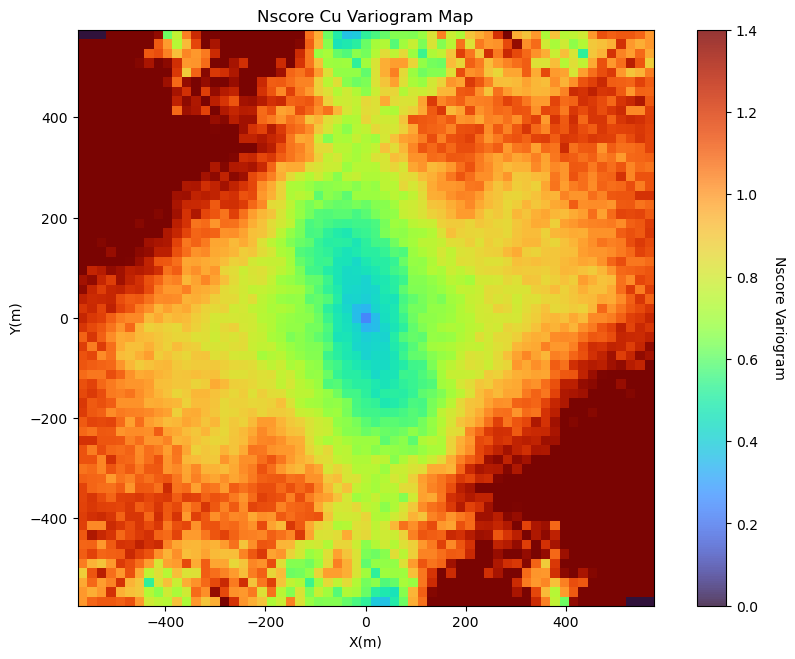

The shape of the output is (61, 61)


In [25]:
cmap = "turbo"
vmap, npmap = geostats.varmapv(df,'EAST', 'NORTH','nscore',tmin=-999,tmax=999,nxlag=30,nylag=30,dxlag=7,dylag=7,minnp=1,isill=1)

plt.subplot(121)
GSLIB.pixelplt_st(vmap,-575,575,-575,575,7,0,1.4,'Nscore Cu Variogram Map','X(m)','Y(m)','Nscore Variogram',cmap)


plt.subplots_adjust(left=0.0, bottom=0.0, right=3.0, top=1.2, wspace=0.2, hspace=0.2)
plt.show()

print('The shape of the output is ' + str(vmap.shape))

In [26]:
# ───────────────────────────────────────────────
# Variogram Parameter Setup (GSLIB/GeoStatSpy style)
# ───────────────────────────────────────────────

tmin = -99999         # Minimum value threshold (no trimming applied here)
tmax = 99999          # Maximum value threshold (no trimming applied here)

lag_dist = 7          # Lag spacing (distance between successive lags in variogram)
lag_tol = lag_dist*0.5  # Lag tolerance (half lag distance allows ±3.5 units tolerance)

nlag = 30             # Number of lag bins to compute the variogram over

bandh = 9999.9        # Bandwidth (across-strike tolerance); very large value disables band restriction (omnidirectional)

atol = 15           # Azimuth tolerance (in degrees); allows matching directions within ±22.5° of specified azimuth

isill = 1             # Sill standardisation (1 = experimental variogram is normalised to sill = 1)

azi_mat = [0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165]
                     # Azimuth directions (in degrees) to compute directional variograms
                     # Note: there’s a duplication of 135 – check for typo or intentional redundancy

xlimax = lag_dist * nlag  # Maximum distance on x-axis for variogram plot (controls display range)

min_samples = 3      # Minimum number of pairs required per lag to compute a valid semivariance


In [27]:
150+15

165

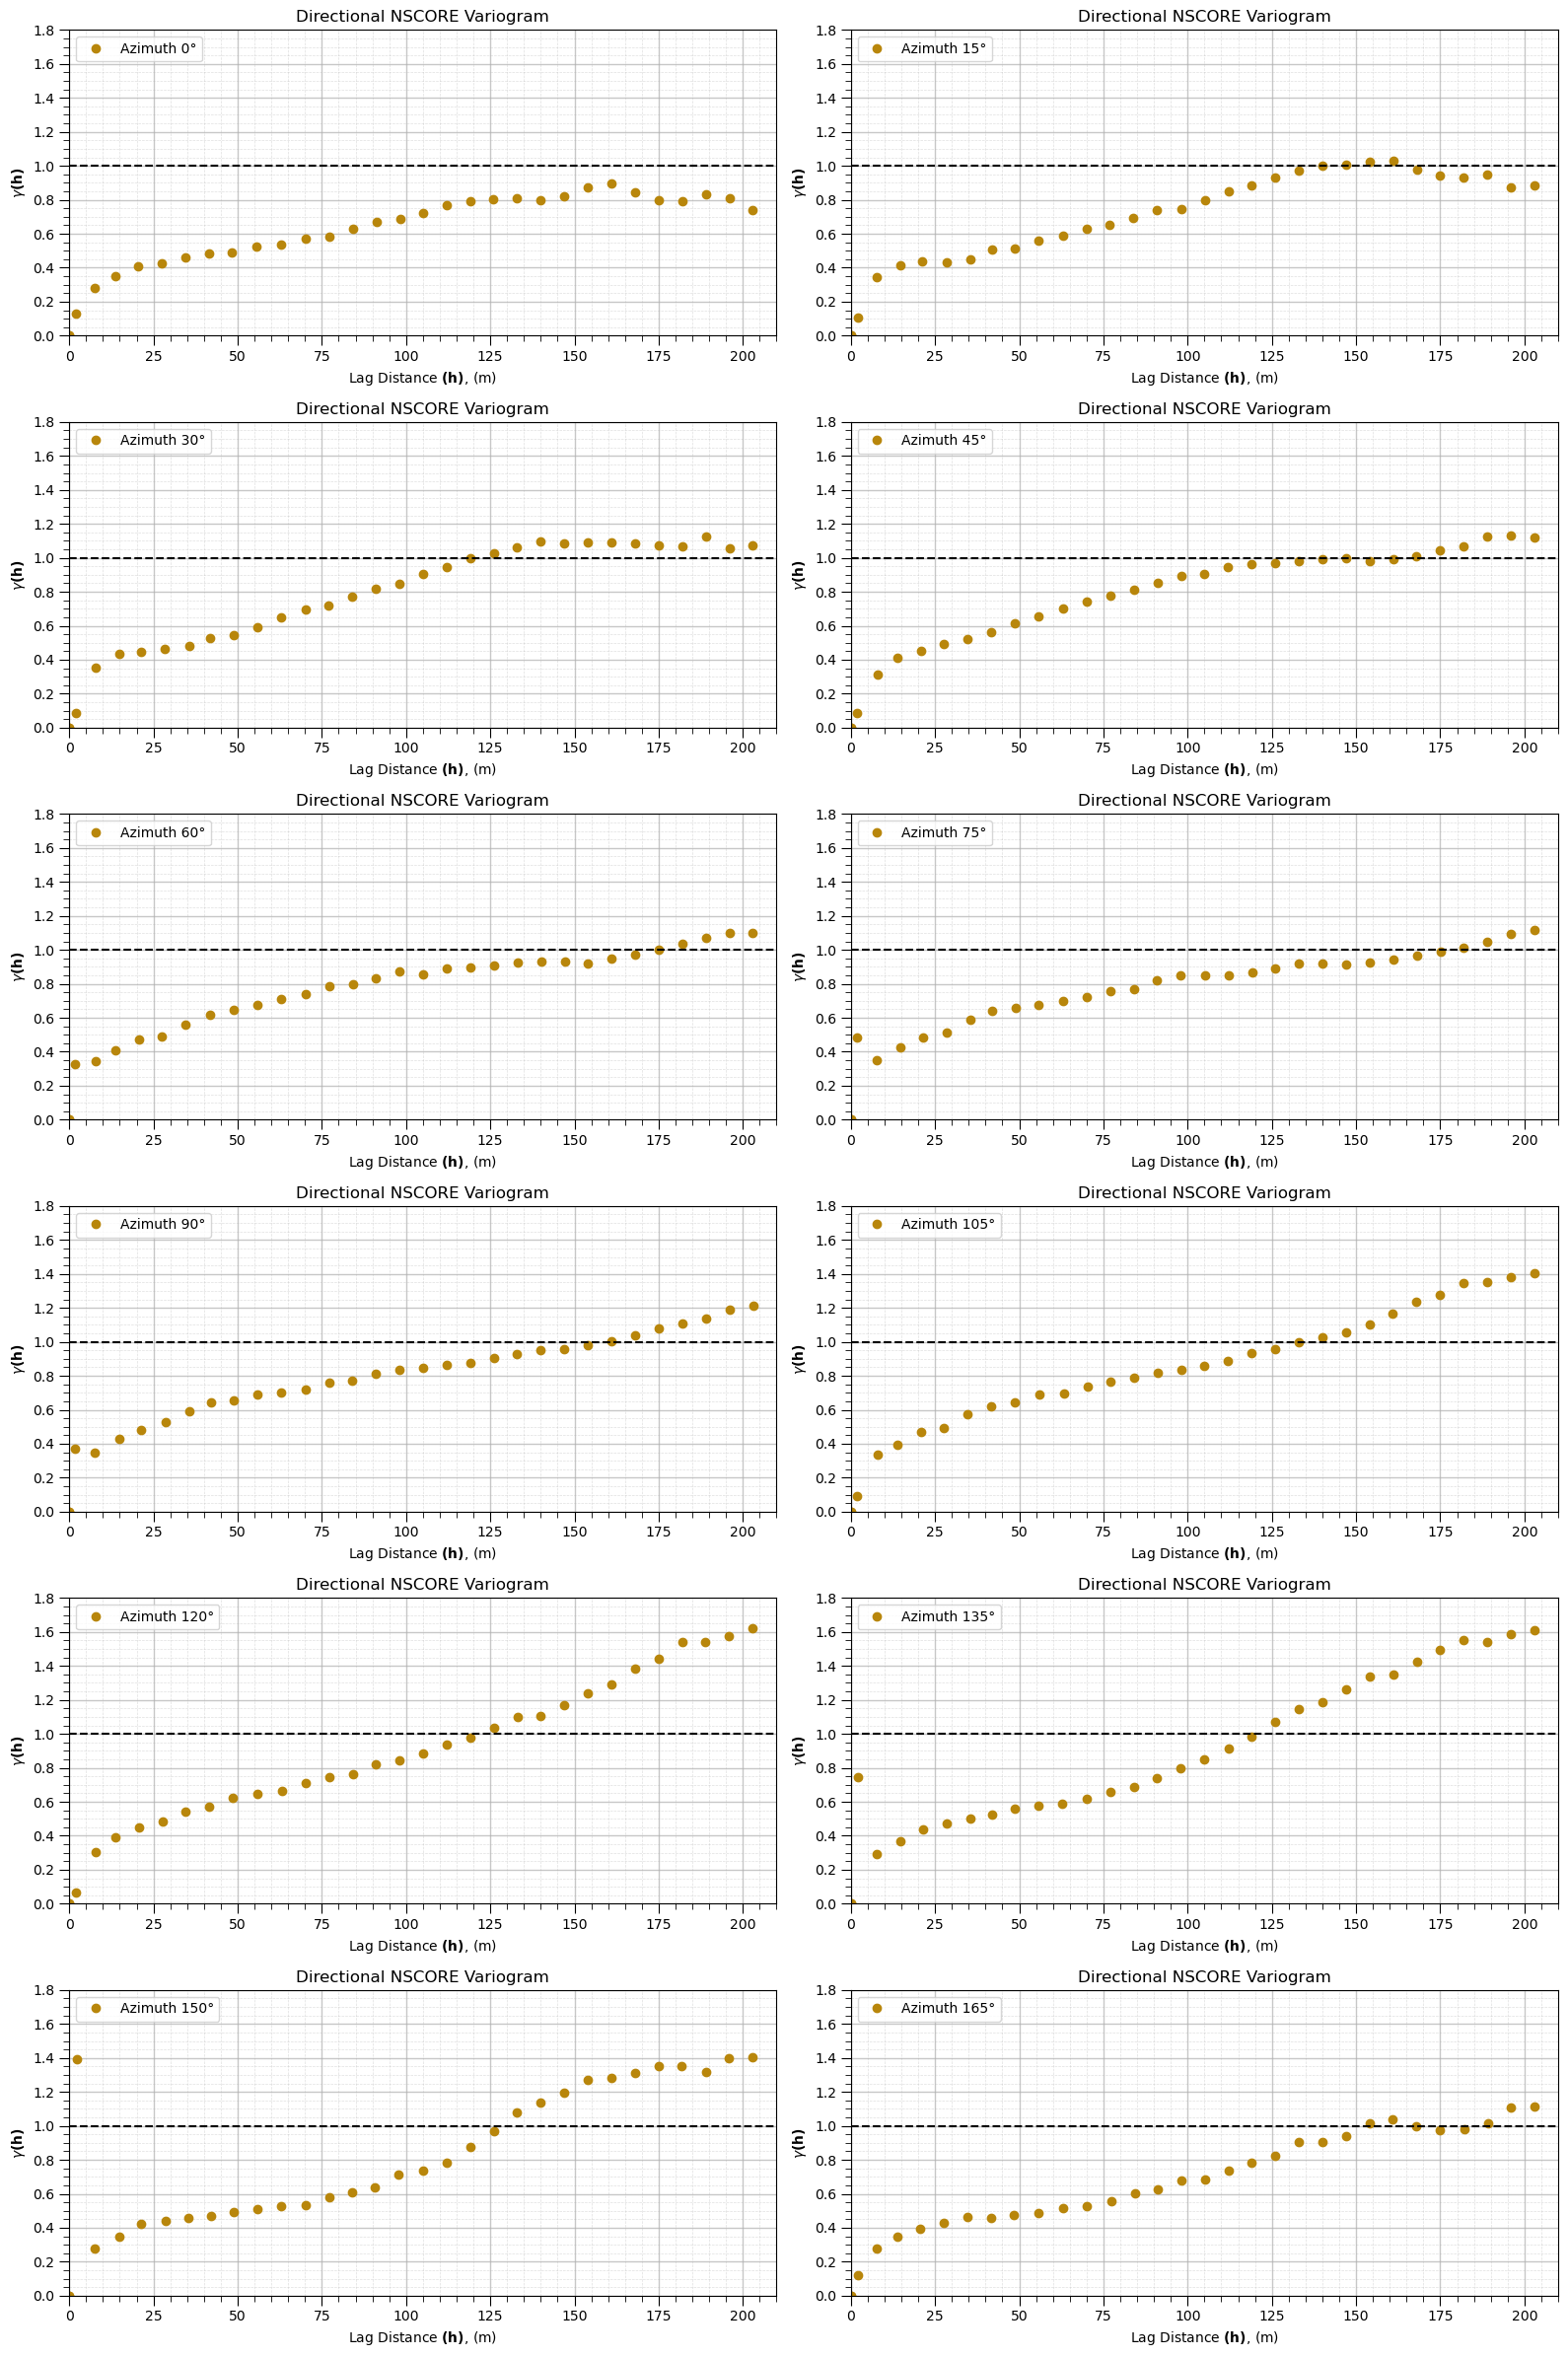

In [28]:
# ──────────────────────────────
# Custom grid helper function
# ──────────────────────────────
def add_grid(ax):
    ax.grid(True, which='major', linewidth=1.0, alpha=0.7)
    ax.grid(True, which='minor', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

# Arrays to store results
lag = np.zeros((len(azi_mat), nlag + 2))
gamma = np.zeros((len(azi_mat), nlag + 2))
npp = np.zeros((len(azi_mat), nlag + 2))

# ──────────────────────────────
# Create subplots
# ──────────────────────────────
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(16, 24))
axes = axes.flatten()

for iazi, azimuth in enumerate(azi_mat):
    lag[iazi, :], gamma[iazi, :], npp[iazi, :] = geostats.gamv(
        df, 'EAST', 'NORTH', "nscore", tmin, tmax,
        lag_dist, lag_tol, nlag, azimuth, atol, bandh, isill
    )

    ax = axes[iazi]
    ax.plot(lag[iazi, :], gamma[iazi, :], 'o', color='darkgoldenrod', label=f'Azimuth {azimuth}°')
    ax.plot([0, xlimax], [1.0, 1.0], color='black', linestyle='--')
    ax.set_xlim([0, xlimax])
    ax.set_ylim([0, 1.8])
    ax.set_xlabel(r'Lag Distance $\bf(h)$, (m)')
    ax.set_ylabel(r'$\gamma \bf(h)$')
    ax.set_title('Directional NSCORE Variogram')
    ax.legend(loc='upper left')
    add_grid(ax)

# Remove any unused subplots if len(azi_mat) < total panels
for i in range(len(azi_mat), len(axes)):
    fig.delaxes(axes[i])

# ──────────────────────────────
# Layout and save
# ──────────────────────────────
plt.tight_layout()
output_file = os.path.join(image_path, 'Directional_NScore_Variograms.png')
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()


Major direction is 0 azimuth.
Minor direction is 90 azimuth.


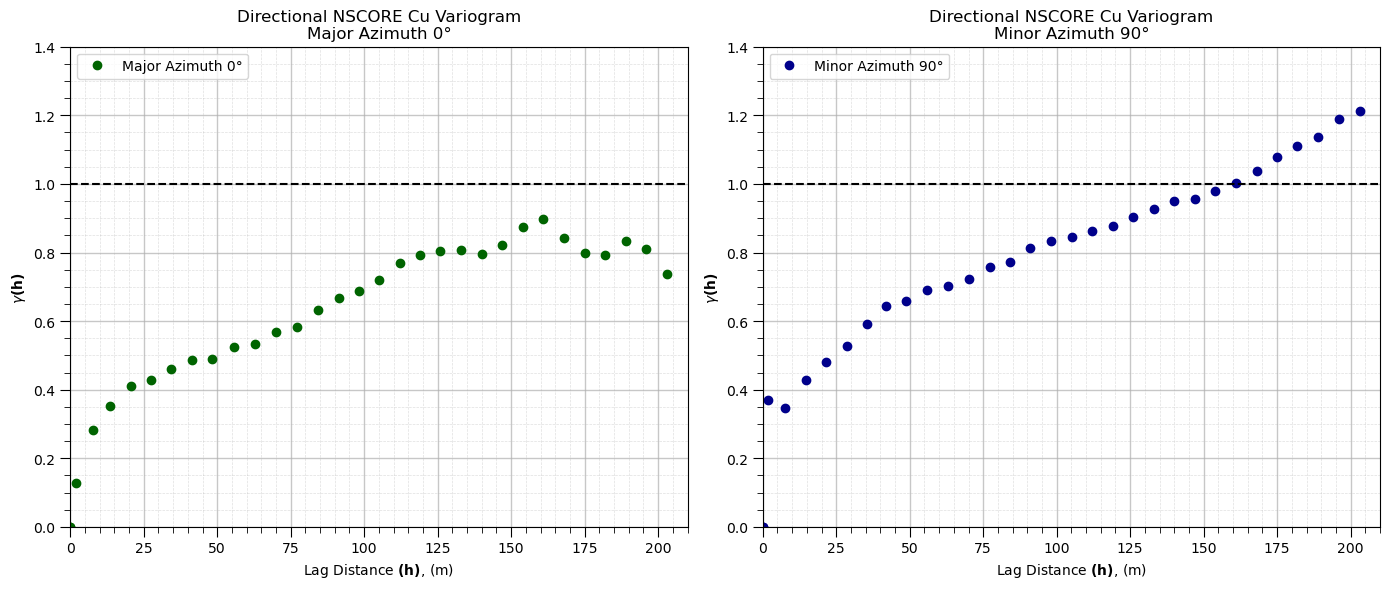

In [29]:
import sys

# ──────────────────────────────
# Custom grid function
# ──────────────────────────────
def add_grid(ax):
    ax.grid(True, which='major', linewidth=1.0, alpha=0.7)
    ax.grid(True, which='minor', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

# ──────────────────────────────
# Select major and minor directions
# ──────────────────────────────
imajor = 0
iminor = 6

print('Major direction is ' + str(azi_mat[imajor]) + ' azimuth.')
print('Minor direction is ' + str(azi_mat[iminor]) + ' azimuth.')

if not abs(azi_mat[imajor] - azi_mat[iminor]) == 90.0:
    print('Major and minor directions must be orthogonal to each other.')
    sys.exit()

# ──────────────────────────────
# Create subplots for major/minor
# ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# ───── Major Direction Plot ─────
ax1.plot(lag[imajor, :], gamma[imajor, :], 'o', color='darkgreen',
         label=f'Major Azimuth {azi_mat[imajor]}°')
ax1.plot([0, xlimax], [1.0, 1.0], color='black', linestyle='--')
ax1.set_xlim([0, xlimax])
ax1.set_ylim([0, 1.4])
ax1.set_xlabel(r'Lag Distance $\bf(h)$, (m)')
ax1.set_ylabel(r'$\gamma \bf(h)$')
ax1.set_title(f'Directional NSCORE Cu Variogram\nMajor Azimuth {azi_mat[imajor]}°')
ax1.legend(loc='upper left')
add_grid(ax1)

# ───── Minor Direction Plot ─────
ax2.plot(lag[iminor, :], gamma[iminor, :], 'o', color='darkblue',
         label=f'Minor Azimuth {azi_mat[iminor]}°')
ax2.plot([0, xlimax], [1.0, 1.0], color='black', linestyle='--')
ax2.set_xlim([0, xlimax])
ax2.set_ylim([0, 1.4])
ax2.set_xlabel(r'Lag Distance $\bf(h)$, (m)')
ax2.set_ylabel(r'$\gamma \bf(h)$')
ax2.set_title(f'Directional NSCORE Cu Variogram\nMinor Azimuth {azi_mat[iminor]}°')
ax2.legend(loc='upper left')
add_grid(ax2)

# ──────────────────────────────
# Layout and save
# ──────────────────────────────
plt.tight_layout()
output_file = os.path.join(image_path, 'NSCORE_Major_Minor_Variograms.png')
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()


##### make_variogram function

We use the make_variogram function to make a variogram model 

* a dictionary for compact storage of the variogram model parameters to pass into plotting (below), kriging and simulation methods 

The variogram model parameter include:

* **nug** - nugget effect contribution to sill
* **nst** - number of nested structures (1 or 2)
* **it** - type for this nested structure (1 - spherical, 2 - exponential, 3 - Gaussian)
* **cc** - contribution of each nested structure (contributions + nugget must sum to the sill)
* **azi** - the azimuth for this nested structure of the major direction, the minor is orthogonal
* **hmaj** - the range for this nested structure in the major direction
* **hmin** - the range for this nested structure in the minor direction

Major direction is 0 azimuth.
Minor direction is 90 azimuth.
 x,y,z offsets = 0.0,10.0
 x,y,z offsets = 10.0,1.794896514920806e-08


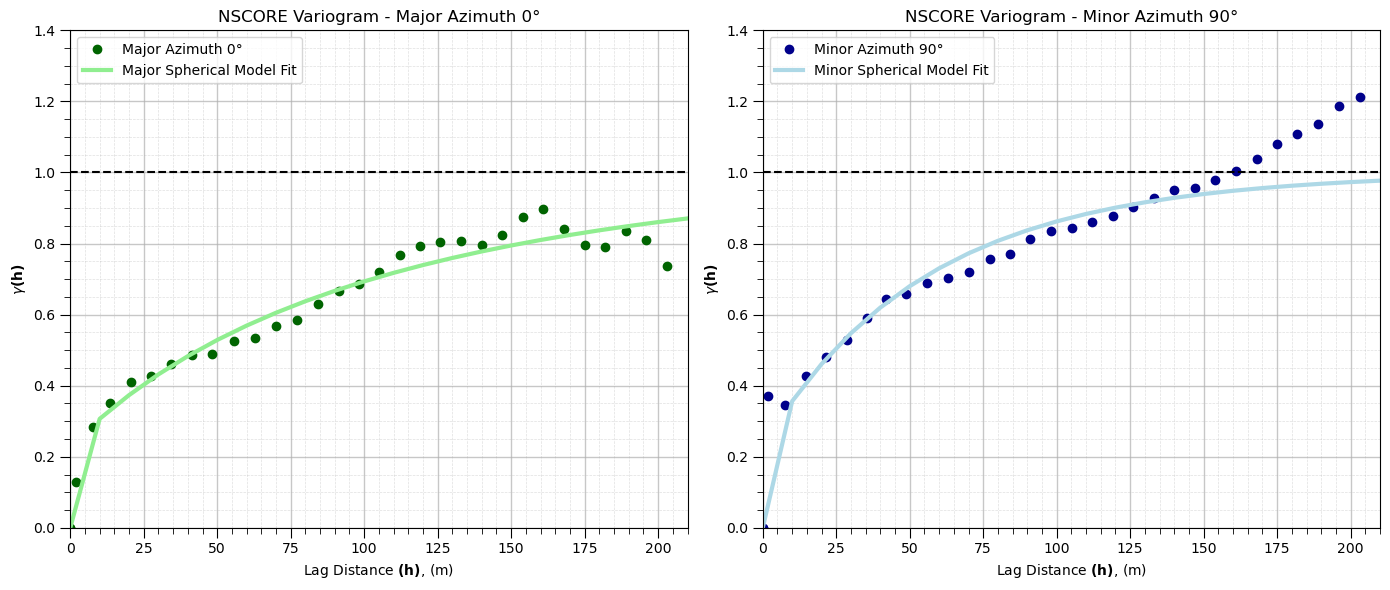

In [30]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ──────────────────────────────
# Ensure image directory exists
# ──────────────────────────────
image_path = 'images'
if not os.path.exists(image_path):
    os.mkdir(image_path)

# ──────────────────────────────
# Custom grid function
# ──────────────────────────────
def add_grid(ax):
    ax.grid(True, which='major', linewidth=1.0, alpha=0.7)
    ax.grid(True, which='minor', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

# ──────────────────────────────
# Select orthogonal directions
# ──────────────────────────────
imajor = 0              # Index in azi_mat for major azimuth (e.g., 0°)
iminor = 6              # Index in azi_mat for minor azimuth (e.g., 135°)

print('Major direction is ' + str(azi_mat[imajor]) + ' azimuth.')
print('Minor direction is ' + str(azi_mat[iminor]) + ' azimuth.')

# Ensure orthogonality between major and minor directions
if not abs(azi_mat[imajor] - azi_mat[iminor]) == 90.0:
    print('Major and minor directions must be orthogonal to each other.')
    sys.exit()

# ──────────────────────────────
# Variogram model parameters
# ──────────────────────────────

# Spherical nested variogram model with 2 structures and a nugget effect
nug = 0.23             # Nugget effect (γ(h) at h≈0); represents microscale variation or measurement error
nst = 2                # Number of nested structures (two spherical components)

# ────── VARIOGRAM STRUCTURE 1 (short-range) ──────
it1    = 2             # Structure type (1 = spherical, 2 = exponential, 3 = Gaussian)
cc1    = 0.15          # Contribution of first structure to sill (partial sill)
azi1   = azi_mat[imajor]  # Azimuth for anisotropy orientation
hmaj1  = 125           # Range in major direction (a)
hmin1  = 110            # Range in minor direction (b)

# ────── VARIOGRAM STRUCTURE 2 (long-range) ──────
it2    = 2             # Structure type (1 = spherical, 2 = exponential, 3 = Gaussian)
cc2    = 1 - (nug + cc1)  # Contribution of second structure (remaining sill to reach 1.0)
azi2   = azi_mat[imajor]  # Azimuth (same as structure 1)
hmaj2  = 400           # Longer range in major direction
hmin2  = 190           # Longer range in minor direction

# ┌───────────────────────────────────────────────┐
# │         ✦ Variogram Structure Summary ✦       │
# ├─────────────┬─────────────────────────────────┤
# │ Nugget (nug)│ 0.28 (random noise/microstructure) │
# ├─────────────┼─────────────────────────────────┤
# │ Structure 1 │ Type: Spherical (it1=1)          │
# │             │ Contribution: 0.30 (cc1)         │
# │             │ Azimuth: {}° (azi1)             │
# │             │ Range Major: 130 m (hmaj1)       │
# │             │ Range Minor:  90 m (hmin1)       │
# ├─────────────┼─────────────────────────────────┤
# │ Structure 2 │ Type: Spherical (it2=1)          │
# │             │ Contribution: {:.2f} (cc2)       │
# │             │ Azimuth: {}° (azi2)             │
# │             │ Range Major: 400 m (hmaj2)       │
# │             │ Range Minor: 190 m (hmin2)       │
# └─────────────┴─────────────────────────────────┘


# ──────────────────────────────
# Create variogram model object
# ──────────────────────────────
vario = GSLIB.make_variogram(nug, nst,
                             it1, cc1, azi1, hmaj1, hmin1,
                             it2, cc2, azi2, hmaj2, hmin2)

# ──────────────────────────────
# Project models into major and minor directions
# ──────────────────────────────
nlag = 70              # Number of lags to model for variogram line
xlag = 10              # Lag interval (distance step)

index_maj, h_maj, gam_maj, cov_maj, ro_maj = geostats.vmodel(nlag, xlag, azi_mat[imajor], vario)
index_min, h_min, gam_min, cov_min, ro_min = geostats.vmodel(nlag, xlag, azi_mat[iminor], vario)

# ──────────────────────────────
# Create subplots
# ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# ───── MAJOR DIRECTION PLOT ─────
ax1.plot(lag[imajor, :], gamma[imajor, :], 'o', color='darkgreen',
         label=f'Major Azimuth {azi_mat[imajor]}°')
ax1.plot(h_maj, gam_maj, color='lightgreen', linewidth=3, label='Major Spherical Model Fit')
ax1.plot([0, xlimax], [1.0, 1.0], color='black', linestyle='--')  # sill line
ax1.set_xlim([0, xlimax])
ax1.set_ylim([0, 1.4])
ax1.set_xlabel(r'Lag Distance $\bf(h)$, (m)')
ax1.set_ylabel(r'$\gamma \bf(h)$')
ax1.set_title(f'NSCORE Variogram - Major Azimuth {azi_mat[imajor]}°')
ax1.legend(loc='upper left')
add_grid(ax1)

# ───── MINOR DIRECTION PLOT ─────
ax2.plot(lag[iminor, :], gamma[iminor, :], 'o', color='darkblue',
         label=f'Minor Azimuth {azi_mat[iminor]}°')
ax2.plot(h_min, gam_min, color='lightblue', linewidth=3, label='Minor Spherical Model Fit')
ax2.plot([0, xlimax], [1.0, 1.0], color='black', linestyle='--')  # sill line
ax2.set_xlim([0, xlimax])
ax2.set_ylim([0, 1.4])
ax2.set_xlabel(r'Lag Distance $\bf(h)$, (m)')
ax2.set_ylabel(r'$\gamma \bf(h)$')
ax2.set_title(f'NSCORE Variogram - Minor Azimuth {azi_mat[iminor]}°')
ax2.legend(loc='upper left')
add_grid(ax2)

# ──────────────────────────────
# Save and display
# ──────────────────────────────
plt.tight_layout()
output_file = os.path.join(image_path, 'NSCORE_Major_Minor_Variograms_WithModel.png')
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()


# End of practical 3 Memo